Import required libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import StratifiedGroupKFold

Load the Movie Dataset

In [4]:
# Load the MovieLens dataset and inspect its first rows, columns,
# data types, and missing values.

# Define the dataset path
data_path = "/movies.csv"

# Load the movie dataset
data = pd.read_csv(data_path)

# Show the first rows
print(data.head())

# Show dataset information
data.info()

# Show the number of missing values in each column
print(data.isnull().sum())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB
movieId    0
title      0
genres     0
dtype: int64


Clean the Text Data

In [5]:
# Remove the movieId column because it is not needed for text classification
df = data.drop(columns=["movieId"])

# Keep only rows where title and genres are available
df = df.dropna(subset=["title", "genres"])

# Define a function to clean movie titles
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\(\d{4}\)", "", text)       # Remove the year in parentheses
    text = re.sub(r"[^a-zA-Z\s]", " ", text)   # Keep only letters and spaces
    text = re.sub(r"\s+", " ", text)            # Remove extra whitespace
    return text.strip()

# Create a cleaned title column
df["title_clean"] = df["title"].apply(clean_text)

Split the Data

In [6]:
# Define features and labels
X = df["title_clean"]
Y = df["genres"]

# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

# Show the number of samples in training and test sets
print("Training samples:", len(Y_train))
print("Test samples:", len(Y_test))

Training samples: 7793
Test samples: 1949


Vectorize Text and Encode Multi-label Genres

In [7]:
# Convert cleaned titles into numerical feature vectors
vectorizer = CountVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Split genre strings by the pipe separator
# Example: "Action|Adventure|Sci-Fi" -> ["Action", "Adventure", "Sci-Fi"]
Y_train_split = Y_train.apply(lambda x: x.split('|'))
Y_test_split = Y_test.apply(lambda x: x.split('|'))

# Convert genre lists into binary multi-label vectors
mlb = MultiLabelBinarizer()
Y_train_bin = mlb.fit_transform(Y_train_split)
Y_test_bin = mlb.transform(Y_test_split)

Train the Multi-label Naive Bayes Model

In [8]:
# Train a One-vs-Rest Multinomial Naive Bayes classifier
clf = OneVsRestClassifier(MultinomialNB(alpha=1.0, fit_prior=True))

# Fit the model on training data
clf.fit(X_train_vec, Y_train_bin)

# Predict genre probabilities for the test set
prediction_prob = clf.predict_proba(X_test_vec)

# Show predicted probabilities for the first five samples
print("Probabilities for first 5 samples:")
print(prediction_prob[0:5])

Probabilities for first 5 samples:
[[2.76666090e-04 1.29526337e-01 1.15097006e-01 4.09252004e-02
  5.47002523e-02 7.33320618e-01 8.07260928e-02 2.72102710e-02
  2.04701679e-01 6.68630678e-02 1.27802625e-03 8.84625856e-02
  4.78111581e-03 1.70120136e-02 4.12380453e-02 8.93537304e-02
  8.23979244e-02 1.57940535e-01 1.92470911e-02 4.83516857e-03]
 [1.41570479e-06 8.79298357e-01 9.45736519e-01 1.44753788e-02
  1.20693263e-03 8.51243447e-03 4.21543621e-04 9.76520185e-05
  3.96851779e-02 2.28178007e-02 6.34794742e-06 4.63548981e-03
  1.25742305e-03 2.33174295e-04 6.38321558e-04 2.61732207e-03
  9.87844605e-01 1.17640880e-02 1.55698359e-04 4.69222521e-05]
 [3.46464776e-03 1.87475940e-01 1.29603490e-01 6.09521365e-02
  6.78814321e-02 3.88682151e-01 1.22417554e-01 4.63236238e-02
  4.48607725e-01 8.07134608e-02 9.49570127e-03 9.79083793e-02
  1.55267548e-02 3.32349544e-02 6.05671757e-02 1.66688053e-01
  9.85499808e-02 1.92095470e-01 3.92660080e-02 1.70665982e-02]
 [2.96629900e-04 3.17602186e-02 

Predict Genres and Calculate Exact Match Accuracy

In [9]:
# Predict binary genre labels for the test set
prediction = clf.predict(X_test_vec)

# Convert binary predictions back to readable genre names
predicted_genres = mlb.inverse_transform(prediction)

# Show predicted genres for the first five samples
print("\nPredicted genres for first 5 samples:")
print(predicted_genres[:5])

# Calculate exact match accuracy for multi-label prediction
exact_match_accuracy = np.mean(prediction == Y_test_bin)
print(f"\nExact Match Accuracy: {exact_match_accuracy * 100:.1f}%")



Predicted genres for first 5 samples:
[('Comedy',), ('Action', 'Adventure', 'Sci-Fi'), (), ('Drama',), ('Drama',)]

Exact Match Accuracy: 89.4%


Classification Report

In [10]:
# Print a detailed classification report for each genre
print("\nClassification Report:")
print(
    classification_report(
        Y_test_bin,
        prediction,
        target_names=mlb.classes_,
        zero_division=0
    )
)


Classification Report:
                    precision    recall  f1-score   support

(no genres listed)       0.00      0.00      0.00         7
            Action       0.63      0.21      0.31       367
         Adventure       0.55      0.10      0.17       253
         Animation       0.71      0.04      0.07       136
          Children       0.54      0.05      0.09       135
            Comedy       0.60      0.40      0.48       727
             Crime       0.64      0.06      0.10       245
       Documentary       0.00      0.00      0.00        79
             Drama       0.60      0.36      0.45       865
           Fantasy       0.54      0.05      0.09       150
         Film-Noir       0.00      0.00      0.00        13
            Horror       0.90      0.13      0.23       215
              IMAX       0.00      0.00      0.00        37
           Musical       0.00      0.00      0.00        75
           Mystery       0.00      0.00      0.00       101
           Roma

Compute ROC Metrics

In [11]:
# Ensure that prediction probabilities are available
if prediction_prob is None:
    raise ValueError(
        "Critical error: prediction_prob is None. "
        "Make sure clf.predict_proba(X_test_vec) has been executed."
    )

# Convert dense or sparse data to a one-dimensional NumPy array
def get_1d_array(data):
    if sp.issparse(data):
        return data.toarray().ravel()
    return np.asarray(data).ravel()

# Get the number of genre classes
n_classes = Y_test_bin.shape[1]

# Create dictionaries to store ROC metrics
fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC curve and AUC for each genre separately
for i in range(n_classes):
    y_true_i = get_1d_array(Y_test_bin[:, i])
    y_score_i = get_1d_array(prediction_prob[:, i])

    fpr[i], tpr[i], _ = roc_curve(y_true_i, y_score_i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC across all genres
y_true_micro = get_1d_array(Y_test_bin)
y_score_micro = get_1d_array(prediction_prob)

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_micro, y_score_micro)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

Plot ROC Curves

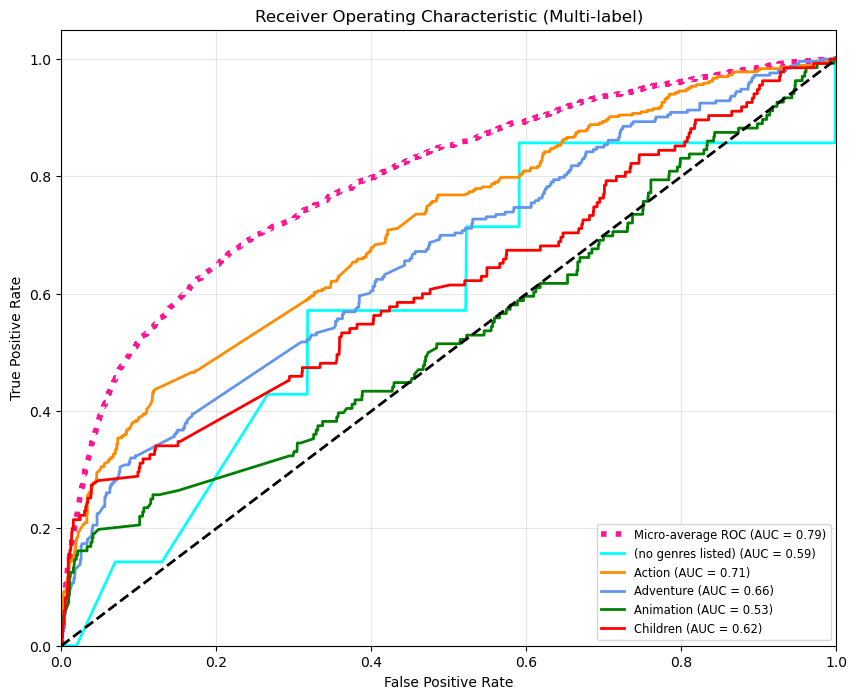

Micro-average ROC-AUC Score: 0.7939


In [12]:
# Create the ROC curve plot
plt.figure(figsize=(10, 8))
lw = 2

# Plot the micro-average ROC curve
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})',
    color='deeppink',
    linestyle=':',
    linewidth=4
)

# Plot ROC curves for the first five genres
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
classes_to_plot = range(min(5, n_classes))

for i, color in zip(classes_to_plot, colors):
    genre_name = mlb.classes_[i]
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=lw,
        label=f'{genre_name} (AUC = {roc_auc[i]:.2f})'
    )

# Plot the diagonal chance line
plt.plot([0, 1], [0, 1], 'k--', lw=lw)

# Set plot limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Set axis labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Multi-label)')

# Show legend and grid
plt.legend(loc="lower right", fontsize='small')
plt.grid(alpha=0.3)

# Display the plot
plt.show()

# Print micro-average ROC-AUC score
print(f"Micro-average ROC-AUC Score: {roc_auc['micro']:.4f}")